In [24]:
#A.3

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

num_cols = ['duration', 'campaign', 'euribor3m', 'No. employed']

outlier_stats = []

for col in num_cols:
    series = pd.to_numeric(df[col], errors='coerce')
    
    zscores = zscore(series.dropna())
    z_outlier_count = (np.abs(zscores) > 3).sum()
    z_outlier_ratio = round(z_outlier_count / series.dropna().shape[0] * 100, 2)

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_outlier_count = ((series < lower) | (series > upper)).sum()
    iqr_outlier_ratio = round(iqr_outlier_count / series.dropna().shape[0] * 100, 2)

    outlier_stats.append([
        col,
        z_outlier_count, f"{z_outlier_ratio}%",
        iqr_outlier_count, f"{iqr_outlier_ratio}%"
    ])

outlier_df = pd.DataFrame(outlier_stats, columns=[
    "Attribute", "Z-Score Outliers", "Z-Score Ratio",
    "IQR Outliers", "IQR Ratio"
])
display(outlier_df)

,Attribute,Z-Score Outliers,Z-Score Ratio,IQR Outliers,IQR Ratio
0,duration,64,2.43%,196,7.44%
1,campaign,49,1.86%,146,5.54%
2,euribor3m,1,0.04%,1,0.04%
3,No. employed,0,0.0%,0,0.0%


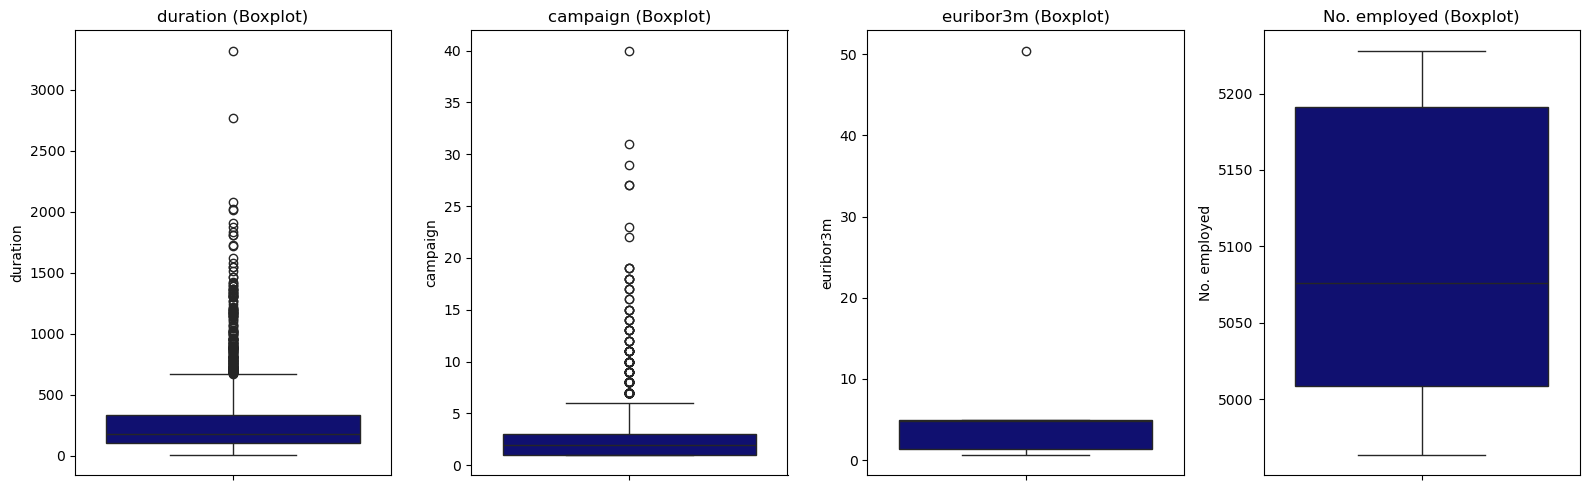

In [40]:
plt.figure(figsize=(16, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=pd.to_numeric(df[col], errors='coerce'), color='navy')
    plt.title(f'{col} (Boxplot)')
plt.tight_layout()
plt.show()

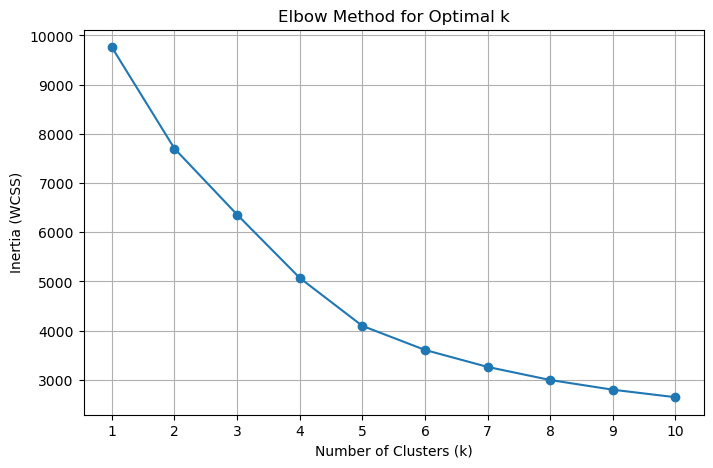

In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

selected_columns = ['age', 'duration', 'campaign', 'No. employed']
df['No. employed'] = pd.to_numeric(df['No. employed'], errors='coerce')
cluster_df = df[selected_columns].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(k_range)
plt.grid(True)
plt.show()

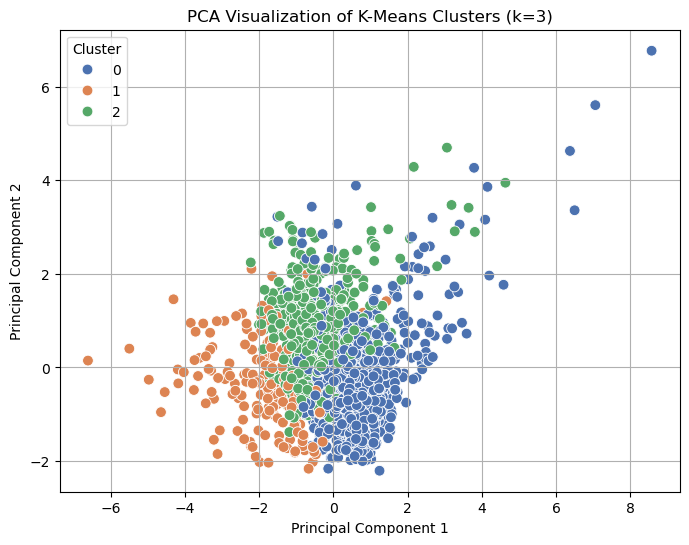

In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

selected_columns = ['age', 'duration', 'campaign', 'No. employed']
df['No. employed'] = pd.to_numeric(df['No. employed'], errors='coerce')
cluster_df = df[selected_columns].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="deep", s=60)
plt.title("PCA Visualization of K-Means Clusters (k=3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_37745/749242468.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=poutcome_group, x='poutcome', y='Term Deposit', ax=axs[0], palette='Blues')
/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_37745/749242468.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month_group, x='month', y='Term Deposit', ax=axs[1], palette='Blues')
/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_37745/749242468.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=co

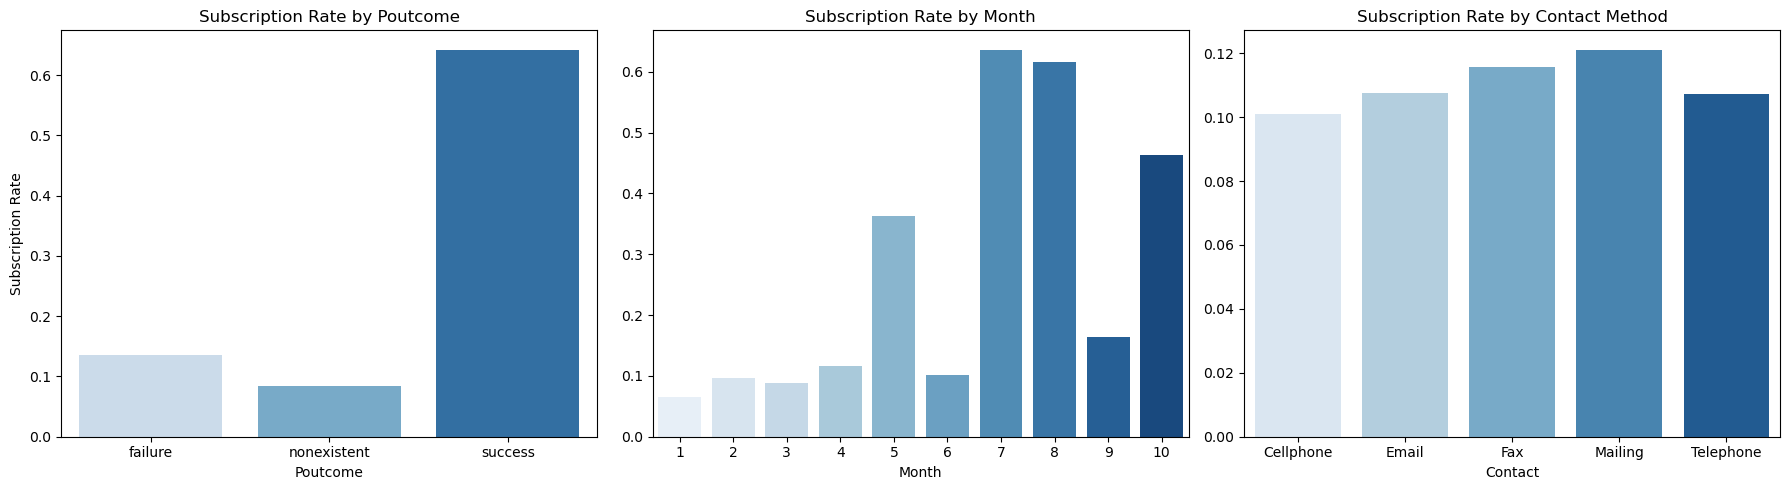

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv" 
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

df['Term Deposit'] = pd.to_numeric(df['Term Deposit'], errors='coerce')

poutcome_group = df.groupby('poutcome')['Term Deposit'].mean().reset_index()
month_group = df.groupby('month')['Term Deposit'].mean().reset_index()
contact_group = df.groupby('contact')['Term Deposit'].mean().reset_index()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=poutcome_group, x='poutcome', y='Term Deposit', ax=axs[0], palette='Blues')
axs[0].set_title('Subscription Rate by Poutcome')
axs[0].set_ylabel('Subscription Rate')
axs[0].set_xlabel('Poutcome')

sns.barplot(data=month_group, x='month', y='Term Deposit', ax=axs[1], palette='Blues')
axs[1].set_title('Subscription Rate by Month')
axs[1].set_ylabel('')
axs[1].set_xlabel('Month')

sns.barplot(data=contact_group, x='contact', y='Term Deposit', ax=axs[2], palette='Blues')
axs[2].set_title('Subscription Rate by Contact Method')
axs[2].set_ylabel('')
axs[2].set_xlabel('Contact')

plt.tight_layout()
plt.show()

In [48]:
print(df.groupby('poutcome')['Term Deposit'].mean())

poutcome
failure        0.134948
nonexistent    0.084813
success        0.642105
Name: Term Deposit, dtype: float64


In [93]:
#B.1.1 Equi-width binning
import pandas as pd

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

num_bins = 5
min_age = df['age'].min()
max_age = df['age'].max()
bin_width = (max_age - min_age) / num_bins

bins = [min_age + i * bin_width for i in range(num_bins + 1)]
labels = [f"Bin{i+1}" for i in range(num_bins)]

df['EW'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)

print("Equi-width binning applied successfully")

Equi-width binning applied successfully


/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_28751/1096876232.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='EW', palette='Blues')


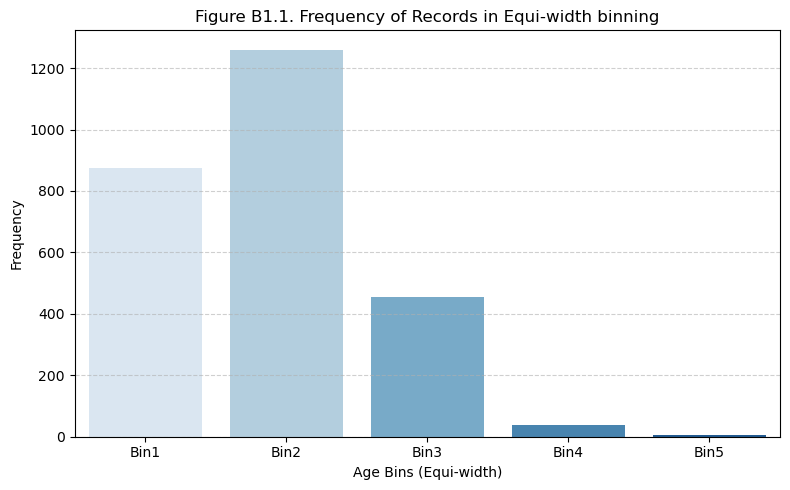

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='EW', palette='Blues')
plt.title('Figure B1.1. Frequency of Records in Equi-width binning')
plt.xlabel('Age Bins (Equi-width)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [103]:
new_df = df[['age', 'EW']]

with pd.ExcelWriter(save_path) as writer:
    new_df.to_excel(writer, sheet_name="Age with Bins", index=False)
    bin_counts.to_excel(writer, sheet_name="Bin Counts", index=False)

In [111]:
#B.1.2 Equi-depth binning

In [135]:
import pandas as pd

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

num_bins = 5
labels = [f"Bin{i+1}" for i in range(num_bins)]
df['ED'] = pd.qcut(df['age'], q=num_bins, labels=labels)

print("Equi-depth binning applied successfully")

Equi-depth binning applied successfully


/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_28751/383476550.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ED', palette='Greens')


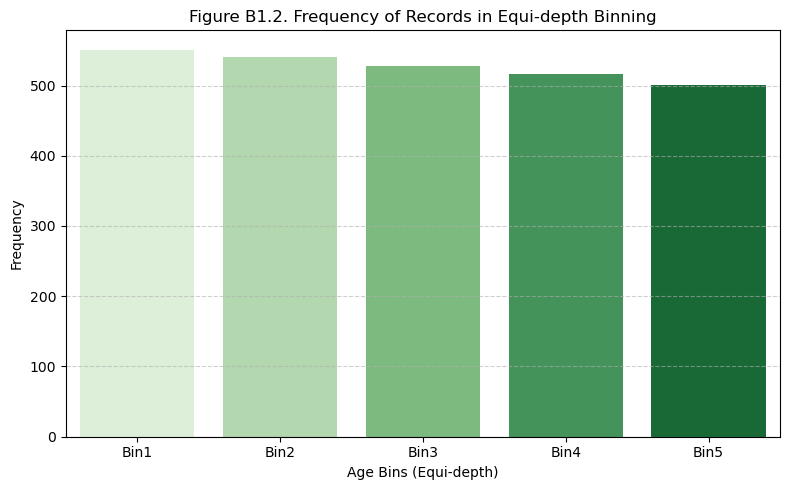

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ED', palette='Greens')
plt.title('Figure B1.2. Frequency of Records in Equi-depth Binning')
plt.xlabel('Age Bins (Equi-depth)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [139]:
new_df = pd.DataFrame({
    'age': df['age'], 'ED': df['ED'] 
})

bin_counts = pd.DataFrame({
    'EF': labels,
    'Count': df['ED'].value_counts().sort_index().values
})

with pd.ExcelWriter(save_path) as writer:
    new_df.to_excel(writer, sheet_name="Age with Bins", index=False)
    bin_counts.to_excel(writer, sheet_name="Bin Counts", index=False)

In [153]:
import pandas as pd

file_ew = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/B1.1_EquiWidth_Result.xlsx"
file_ed = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/B1.2_EquiDepth_Result.xlsx"

df_ew = pd.read_excel(file_ew, sheet_name="Age with Bins")
df_ed = pd.read_excel(file_ed, sheet_name="Age with Bins")

merged_df = pd.concat([df_ew.set_index('age'), df_ed.set_index('age')], axis=1).reset_index()

merged_df = merged_df[['age', 'EW', 'ED']]

save_path = "/Users/seungwookim/Desktop/B1_Final_EW_ED.xlsx"
merged_df.to_excel(save_path, index=False)

print(f"Merged file saved")

Merged file saved


In [ ]:
#B.2.1 Min-Max Normalization

In [73]:
import pandas as pd

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

target_col = 'passed days'
df_filtered = df[df[target_col] != 999].copy()

min_val = df_filtered[target_col].min()
max_val = df_filtered[target_col].max()

df_filtered['min_max'] = df_filtered[target_col].apply(
    lambda x: (x - min_val) / (max_val - min_val)
)

print("Min-Max Normalization applied successdully")

Min-Max Normalization applied successdully


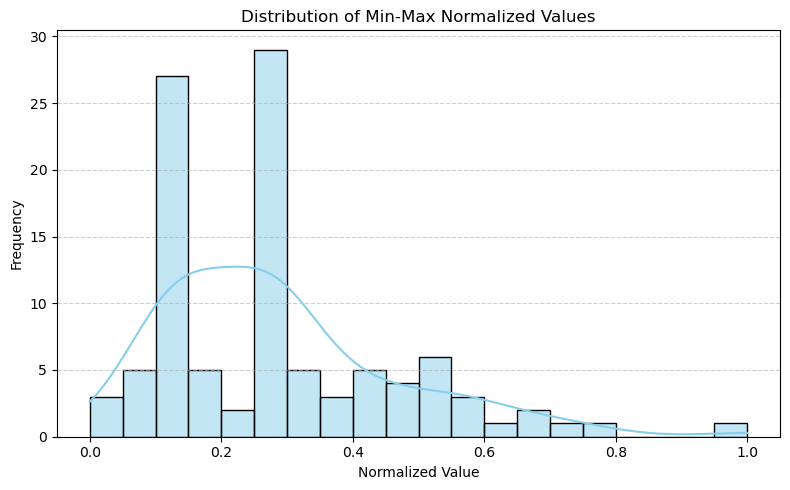

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df_filtered, x='min_max', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Min-Max Normalized Values')
plt.xlabel('Normalized Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [77]:
output_df = df_filtered[[target_col, 'min_max']]

save_path = "/Users/seungwookim/Desktop/B2.2_MinMax_Filtered_Result.xlsx"
output_df.to_excel(save_path, index=False)

In [19]:
#B.2.2 Z-Score NOrmalization

In [79]:
import pandas as pd

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

target_col = 'passed days'
df_filtered = df[df[target_col] != 999].copy()

mean_val = df_filtered[target_col].mean()
std_val = df_filtered[target_col].std()

df_filtered['Z-Score'] = df_filtered[target_col].apply(
    lambda x: (x - mean_val) / std_val
)

print("Z-score normalization applied successfully")

Z-score normalization applied successfully


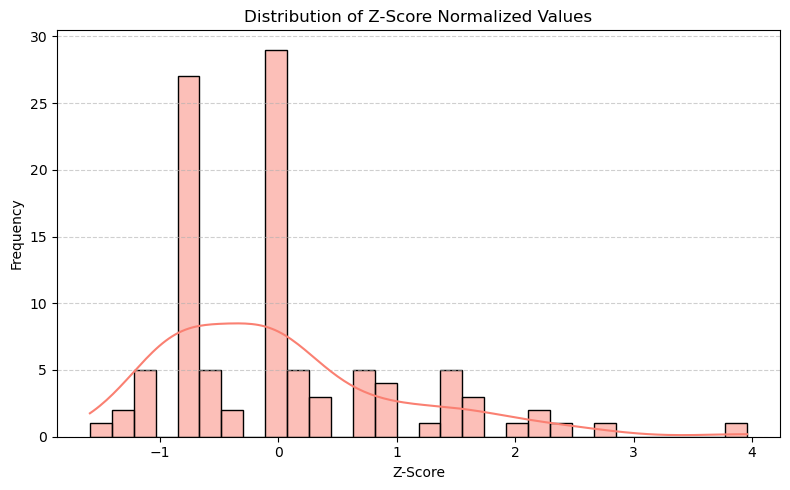

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df_filtered, x='Z-Score', bins=30, kde=True, color='salmon')
plt.title('Distribution of Z-Score Normalized Values')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [83]:
output_df = df_filtered[[target_col, 'Z-Score']]

save_path = "/Users/seungwookim/Desktop/B2.2_ZScore_Filtered_Result.xlsx"
output_df.to_excel(save_path, index=False)

In [63]:
#combined two excel files

In [87]:
import pandas as pd

file_minmax = "/Users/seungwookim/Desktop/B2.2_MinMax_Filtered_Result.xlsx"
file_zscore = "/Users/seungwookim/Desktop/B2.2_ZScore_Filtered_Result.xlsx"

df_minmax = pd.read_excel(file_minmax).reset_index(drop=True)
df_zscore = pd.read_excel(file_zscore).reset_index(drop=True)

df_minmax['Z-Score'] = df_zscore['Z-Score']

save_path = "/Users/seungwookim/Desktop/B3_Normalization_Combined.xlsx"
df_minmax.to_excel(save_path, index=False)

In [1]:
#B.3 Discretisation

In [33]:
import pandas as pd

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

target_col = 'variation rate'
df['variation_class'] = pd.cut(df[target_col], bins=3, labels=['Low', 'Medium', 'High'])

print("discretization applied successfully")

discretization applied successfully


/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_42500/1705699458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='variation_class', palette='pastel')


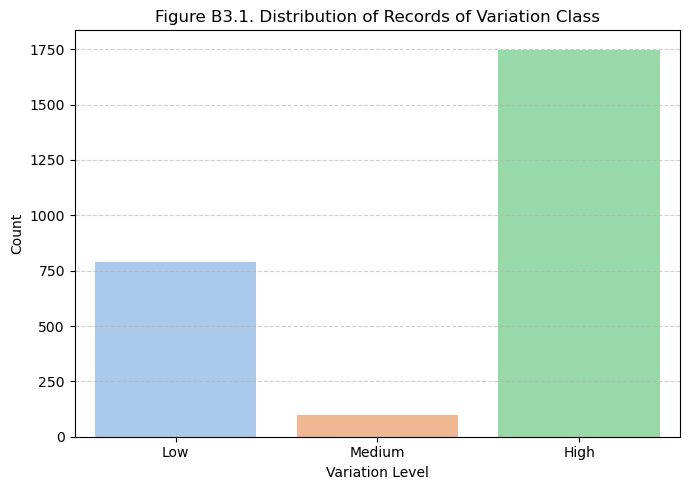

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='variation_class', palette='pastel')
plt.title('Figure B3.1. Distribution of Records of Variation Class')
plt.xlabel('Variation Level')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [37]:
output_df = pd.DataFrame({
    'variation_rate': df['variation rate'],
    'result': df['variation_class']
})

save_path = "/Users/seungwookim/Desktop/B3_Variation_Classes.xlsx"
output_df.to_excel(save_path, index=False)

In [1]:
#B.4 Count Attributes Contact

In [7]:
import pandas as pd

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

contact_counts = df['contact'].value_counts().reset_index()
contact_counts.columns = ['Contact Type', 'Count']

display(contact_counts)

,Contact Type,Count
0,Fax,545
1,Cellphone,545
2,Telephone,522
3,Mailing,512
4,Email,512


In [9]:
#B.4 Binarisation

In [15]:
import pandas as pd

file_path = "/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 2/14588899.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

df['Result'] = df['contact'].str.lower().map({
    'cellphone': 1,
    'telephone': 1,
    'fax': 0,
    'mailing': 0,
    'email': 0
})

print("Succesfully binarized")

Succesfully binarized


In [21]:
contact_map = df[['contact', 'Result']].drop_duplicates().reset_index(drop=True)

display(contact_map)

,contact,Result
0,Mailing,0
1,Fax,0
2,Email,0
3,Cellphone,1
4,Telephone,1


In [23]:
output_df = df[['contact', 'Result']]

save_path = "/Users/seungwookim/Desktop/B4_Contact_Binarized.xlsx"
output_df.to_excel(save_path, index=False)